# Analyse des vaisseaux avec PVBM

In [21]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib.util
import sys
from pathlib import Path
from skimage.morphology import skeletonize, disk, dilation
from skimage.draw import line_aa
from scipy.ndimage import binary_dilation

from PVBM.DiscSegmenter import DiscSegmenter
from PVBM.GeometryAnalysis import GeometricalVBMs
from PVBM.CentralRetinalAnalysis import CREVBMs
from PVBM.FractalAnalysis import MultifractalVBMs

import DiscSegmentation

In [13]:
LABELLED_PATH = Path("../Labelized_Data")
BRUTES_PATH   = Path("../Unlabelized_Data")
MASKS_PATH    = Path("vessels_masks")

def get_paths(nom, hopital):
    nom_corrige = nom.replace("\u2014", "--")
    ann_tif = LABELLED_PATH / f"{hopital.upper()}" / f"{nom_corrige}.tif"
    ann_jpg = LABELLED_PATH / f"{hopital.upper()}" / f"{nom_corrige}.jpg"
    annotee = ann_tif if ann_tif.exists() else ann_jpg
    return {
        "nom":     nom_corrige,
        "hopital": hopital,
        "annotee": annotee,
        "brute":   BRUTES_PATH / hopital.upper() / f"{nom_corrige}.jpg",
        "masque":  MASKS_PATH  / f"Mask_{nom_corrige}.png"
    }


{'nom': 'BOM-2114-34-OG', 'hopital': 'Caen', 'annotee': PosixPath('../Labelized_Data/CAEN/BOM-2114-34-OG.tif'), 'brute': PosixPath('../Unlabelized_Data/CAEN/BOM-2114-34-OG.jpg'), 'masque': PosixPath('vessels_masks/Mask_BOM-2114-34-OG.png')}


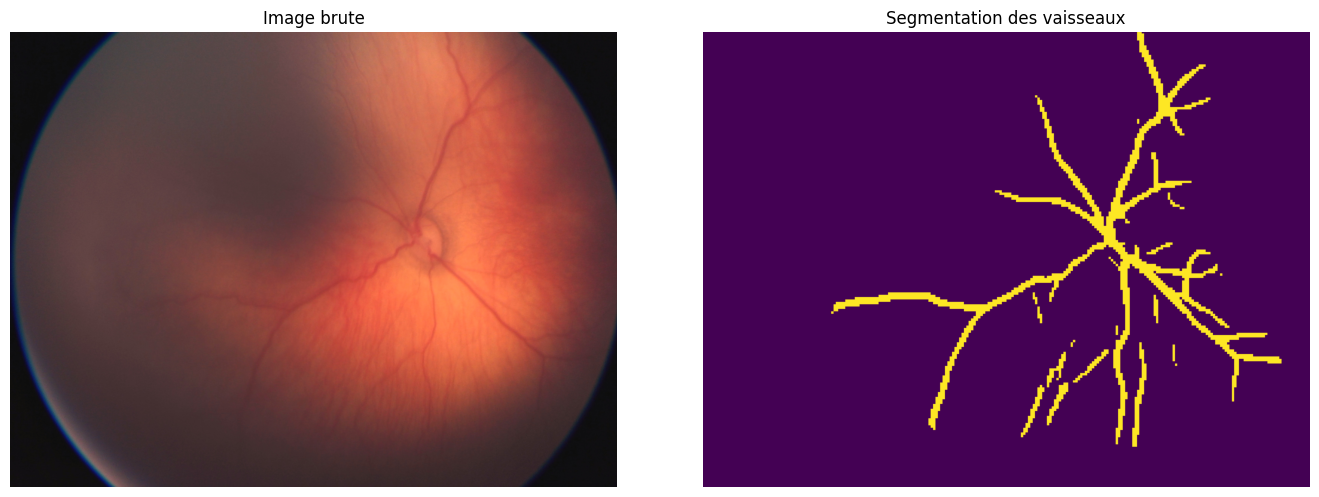

In [14]:
nom = "BOM-2114-34-OG"
hopital= "Caen"
paths = get_paths(nom, hopital)
print(paths)
image = cv2.cvtColor(cv2.imread(str(paths["brute"])), cv2.COLOR_BGR2RGB)
disc_seg= DiscSegmentation.DiscSegmentation(str(paths["annotee"])).get_disc_segmentation()
mask = np.array(Image.open(str(paths["masque"]))) / 255


width, height = mask.shape
disc_seg_r    = cv2.resize(disc_seg, (height, width))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("Image brute")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("Segmentation des vaisseaux")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Masque vaisseaux : (2448, 3264)
Disque rescalé: (2448, 3264)
Model path: /home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/PVBM/lunetv2_odc.onnx


Downloading...
From (original): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX
From (redirected): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX&confirm=t&uuid=fe2b1141-5b0f-41cb-b23e-49851fedb19c
To: /home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/PVBM/lunetv2_odc.onnx
100%|██████████| 125M/125M [00:36<00:00, 3.40MB/s] 


Model downloaded to /home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/PVBM/lunetv2_odc.onnx
Centre : (2168, 1122), Rayon : 149


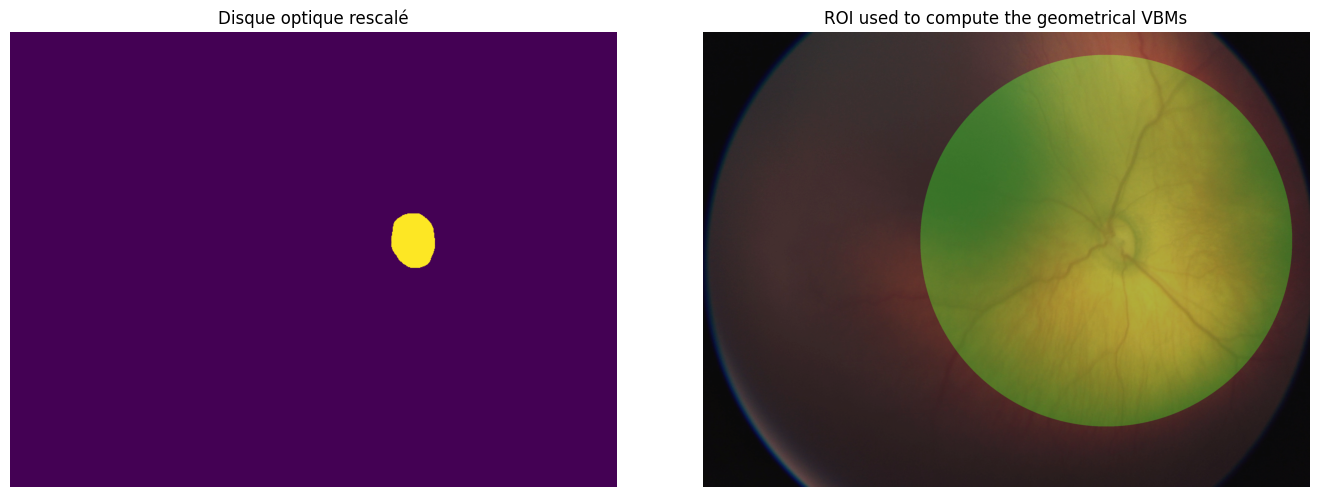

In [15]:
print(f"Masque vaisseaux : {mask.shape}")
print(f"Disque rescalé: {disc_seg_r.shape}")

segmenter = DiscSegmenter()
center, radius, roi, zones_ABC = segmenter.post_processing(
    segmentation=disc_seg_r,
    max_roi_size=1000
)
print(f"Centre : {center}, Rayon : {radius}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(disc_seg_r)
axes[0].set_title("Disque optique rescalé")
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(roi, alpha=0.3)
axes[1].set_title("ROI used to compute the geometrical VBMs")
axes[1].axis("off")

plt.tight_layout()
plt.show()

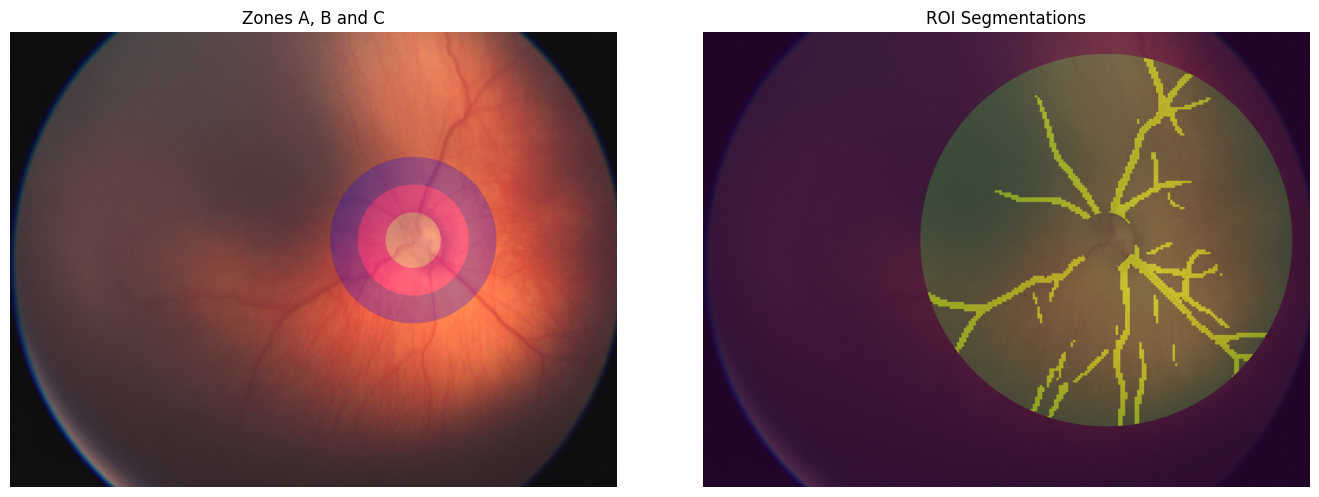

In [16]:
geometricalVBMs = GeometricalVBMs()
segmentation_roi, skeleton_roi = geometricalVBMs.apply_roi(
    segmentation=mask,
    skeleton=skeletonize(mask),
    zones_ABC=zones_ABC,
    roi=roi
)



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image)
axes[0].imshow(zones_ABC/255, alpha=0.5)
axes[0].set_title("Zones A, B and C")
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(segmentation_roi, alpha=0.5)
axes[1].imshow(roi, alpha=0.2)
axes[1].set_title("ROI Segmentations")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Area : 301804.0
Tortuosity Index : 1.1460029600807498
Median Tortuosity : 1.112684958484485
Overall Length : 9118.900212811619
Median Branching angles : 90.0
Start / End / Intersection points : 6 / 23.0 / 19.0


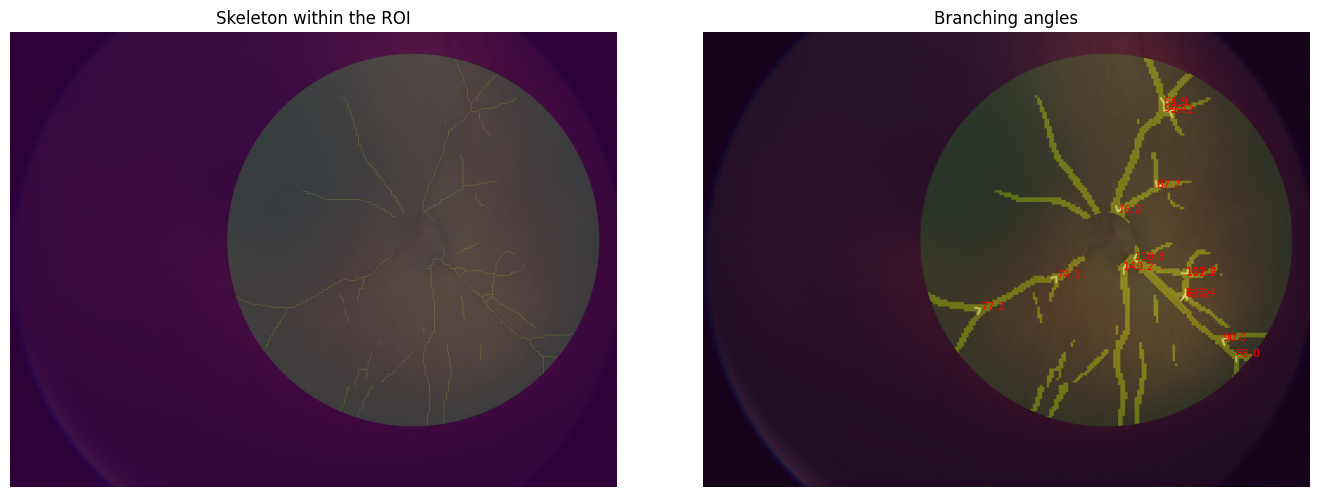

In [18]:
vbms, visual = geometricalVBMs.compute_geomVBMs(
    blood_vessel=segmentation_roi,
    skeleton=skeleton_roi,
    xc=center[0],
    yc=center[1],
    radius=radius
)
area, TI, medTor, ovlen, medianba, startp, endp, interp = vbms
endpoints, interpoints, startpoints, angles_dico, topology_dico = visual

print(f"Area : {area}")
print(f"Tortuosity Index : {TI}")
print(f"Median Tortuosity : {medTor}")
print(f"Overall Length : {ovlen}")
print(f"Median Branching angles : {medianba}")
print(f"Start / End / Intersection points : {startp} / {endp} / {interp}")

def display_angles(angles_dico, img, ax):
    for key, value in angles_dico.items():
        b = key
        if len(value) == 2:
            a, c = value
            if all(x is not None for x in (a, b, c)):
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle = np.arccos(cosine_angle)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                ax.text(b[1], b[0], f"{np.degrees(angle):.1f}", color='red', fontsize=8)
        elif len(value) == 3:
            a, c, d = value
            if all(x is not None for x in (a, b, c, d)):
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle_ac = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle_ac = np.arccos(cosine_angle_ac)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                ax.text(b[1], b[0], f"{np.degrees(angle_ac):.1f}", color='red', fontsize=8)
                bc = np.array(c) - np.array(b)
                bd = np.array(d) - np.array(b)
                cosine_angle_cd = np.dot(bc, bd) / (np.linalg.norm(bc) * np.linalg.norm(bd))
                angle_cd = np.arccos(cosine_angle_cd)
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], d[0], d[1])
                img[rr, cc] = val * 255
                ax.text(b[1], b[0] + 10, f"{np.degrees(angle_cd):.1f}", color='red', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(image)
axes[0].imshow(skeleton_roi, alpha=0.8)
axes[0].imshow(roi, alpha=0.2)
axes[0].set_title("Skeleton within the ROI")
axes[0].axis("off")

img_angles = np.zeros_like(mask)
display_angles(angles_dico, img_angles, axes[1])
img_dilated = binary_dilation(img_angles, structure=np.ones((8, 8))) * 255
axes[1].imshow(image)
axes[1].imshow(segmentation_roi, alpha=0.5)
axes[1].imshow(roi, alpha=0.2)
axes[1].imshow(img_dilated, cmap='gray', alpha=0.3)
axes[1].set_title("Branching angles")
axes[1].axis("off")

plt.tight_layout()
plt.show()

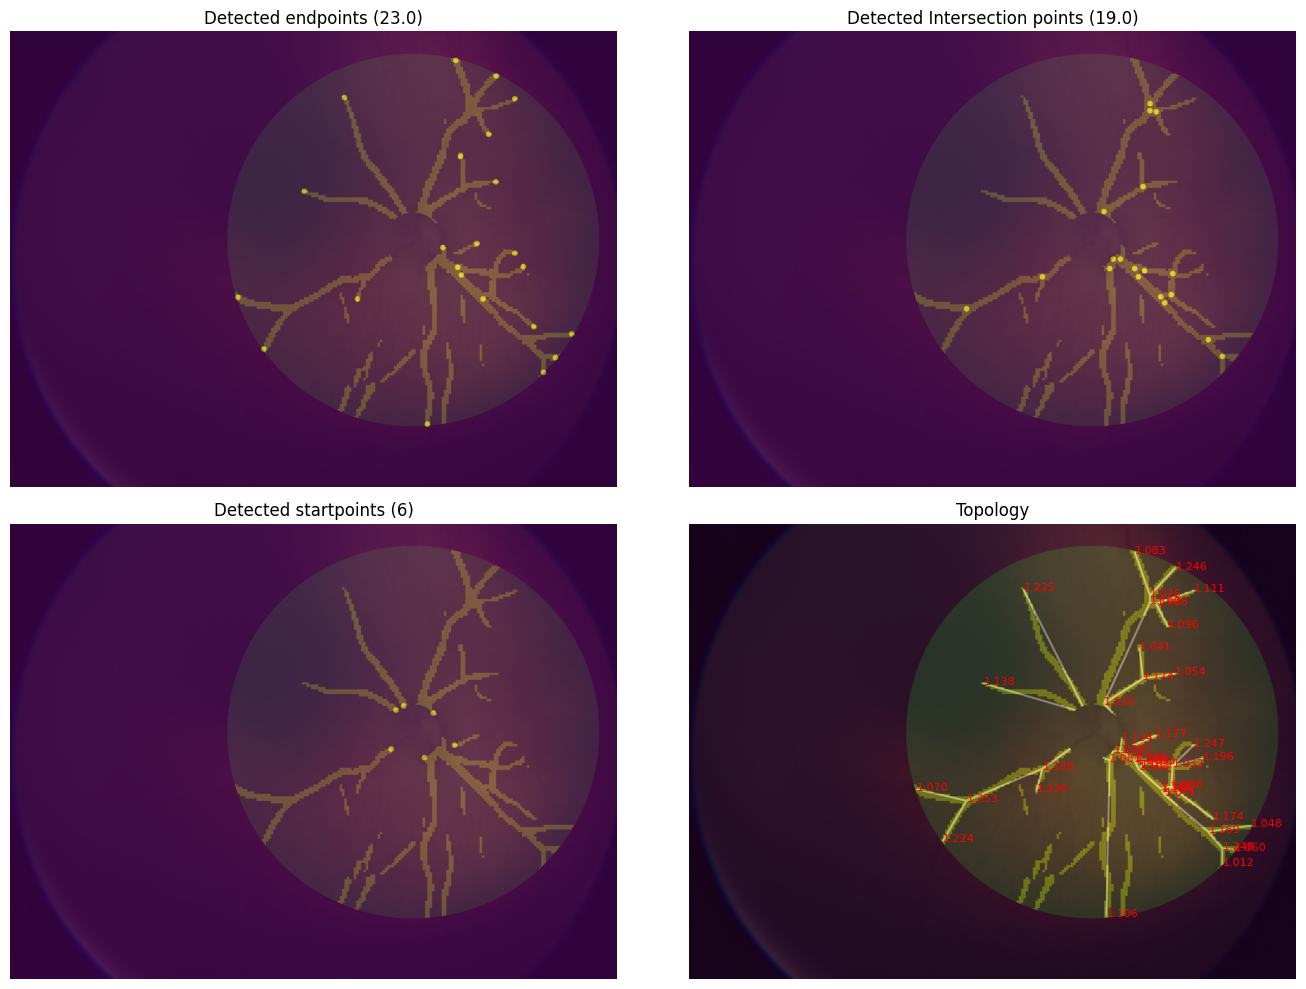

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].imshow(image)
axes[0][0].imshow(segmentation_roi, alpha=0.5)
axes[0][0].imshow(roi, alpha=0.2)
axes[0][0].imshow(mask/100 + dilation(endpoints, disk(15)), alpha=0.5)
axes[0][0].set_title(f"Detected endpoints ({endp})")
axes[0][0].axis("off")

axes[0][1].imshow(image)
axes[0][1].imshow(segmentation_roi, alpha=0.5)
axes[0][1].imshow(roi, alpha=0.2)
axes[0][1].imshow(mask/100 + dilation(interpoints, disk(15)), alpha=0.5)
axes[0][1].set_title(f"Detected Intersection points ({interp})")
axes[0][1].axis("off")

axes[1][0].imshow(image)
axes[1][0].imshow(segmentation_roi, alpha=0.5)
axes[1][0].imshow(roi, alpha=0.2)
axes[1][0].imshow(mask/100 + dilation(startpoints, disk(15)), alpha=0.5)
axes[1][0].set_title(f"Detected startpoints ({startp})")
axes[1][0].axis("off")

img_topo = np.zeros_like(mask)
for key, value in topology_dico.items():
    rr, cc, val = line_aa(key[0], key[1], key[2], key[3])
    img_topo[rr, cc] = val * 255
    axes[1][1].text(key[3], key[2], f"{value[0]/value[1]:.3f}", color='red', fontsize=8)

img_topo_dilated = binary_dilation(img_topo, structure=np.ones((8, 8))) * 255
axes[1][1].imshow(image)
axes[1][1].imshow(segmentation_roi, alpha=0.5)
axes[1][1].imshow(roi, alpha=0.2)
axes[1][1].imshow(img_topo_dilated, cmap='gray', alpha=0.3)
axes[1][1].set_title("Topology")
axes[1][1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
fractalVBMs = MultifractalVBMs(n_rotations = 10,optimize = True, min_proba = 0.0001, maxproba = 0.9999)
D0,D1,D2,SL = fractalVBMs.compute_multifractals(segmentation_roi.copy())
print("The fractal biomarkers are D0: {}, D1: {}, D2: {}, SL: {}".format(D0,D1,D2,SL))

The fractal biomarkers are D0: 1.2757331464963277, D1: 1.3046753799381625, D2: 1.308788406727502, SL: 1.0553853968317386


In [26]:
resultats   = []
segmenter_b = DiscSegmenter()

for mask_file in sorted(MASKS_PATH.iterdir()):
    if not mask_file.name.endswith(".png"):
        continue

    nom = mask_file.stem.replace("Mask_", "")

    paths = None
    for hopital in ["Caen", "Cherbourg"]:
        p = get_paths(nom, hopital)
        if p["annotee"].exists():
            paths = p
            break

    if paths is None:
        print(f"{nom} -> introuvable")
        continue

    print(f"Traitement : {nom} ({paths['hopital']}) ...", end=" ")

    try:
        disc_seg= DiscSegmentation.DiscSegmentation(str(paths["annotee"])).get_disc_segmentation()
        mask_img= np.array(Image.open(str(paths["masque"]))) /255
        width, height= mask_img.shape
        disc_seg_r = cv2.resize(disc_seg, (height, width))

        center, radius, roi, zones_ABC = segmenter_b.post_processing(
            segmentation=disc_seg_r, max_roi_size=1000
        )

        geo = GeometricalVBMs()
        seg_roi, skel_roi = geo.apply_roi(
            segmentation=mask_img,
            skeleton=skeletonize(mask_img),
            zones_ABC=zones_ABC,
            roi=roi
        )
        vbms, _ = geo.compute_geomVBMs(
            blood_vessel=seg_roi, skeleton=skel_roi,
            xc=center[0], yc=center[1], radius=radius
        )
        area, TI, medTor, ovlen, medianba, startp, endp, interp = vbms

        fractals = MultifractalVBMs(n_rotations = 10,optimize = True, min_proba = 0.0001, maxproba = 0.9999)
        D0,D1,D2,SL = fractals.compute_multifractals(seg_roi.copy())

        creVBMs = CREVBMs()
        seg_roi_crev, skel_roi_crev = creVBMs.apply_roi(
            segmentation=mask_img,
            skeleton=skeletonize(mask_img),
            zones_ABC=zones_ABC
        )
        output_crev, _ = creVBMs.compute_central_retinal_equivalents(
            blood_vessel=seg_roi_crev.copy(),
            skeleton=skel_roi_crev.copy(),
            xc=center[0],
            yc=center[1],
            radius=radius,
            artery = True,
        )

        resultats.append({
            "image":nom,
            "hopital": paths["hopital"],
            "area": area,
            "longueur": ovlen,
            "tortuosite": TI,
            "med_tortuosite":  medTor,
            "angle_branchement": medianba,
            "nb_startpoints": startp,
            "nb_endpoints": endp,
            "nb_intersections":  interp,
            "d0": D0,
            "d1": D1,
            "d2":D2,
            "sl": SL,
            "craek": output_crev["craek"],
            "craeh": output_crev["craeh"]
        })

    except Exception as e:
        print(f"-> Erreur : {e}")

df = pd.DataFrame(resultats)
df.to_csv("pvbm_biomarqueurs_vaisseaux.csv", index=False)
print(f"\nTerminé ! {len(df)} images traitées")
display(df)

Model path: /home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/PVBM/lunetv2_odc.onnx
Model already exists, skipping download.
Traitement : ALM-2376--OG (Cherbourg) ... 

/home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mercure/miniconda3/envs/regression/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Traitement : AMI-234833-OG (Caen) ... Potential error 7
Traitement : ANJ-2182-35-OG (Cherbourg) ... Traitement : ANL-2485-33-OD (Caen) ... Traitement : BAC-2593-33-OG (Caen) ... Traitement : BAT-2336--OD (Cherbourg) ... Traitement : BEA-2272-34-OD (Cherbourg) ... Traitement : BEE-2273-34-OG (Cherbourg) ... Traitement : BEM-2070-32-OD (Caen) ... Traitement : BER-2470-34-OG (Caen) ... Traitement : BIS-2564-32-OG (Cherbourg) ... Traitement : BOM-2114-34-OG (Caen) ... Potential error 5
Traitement : BOM-2207-33-OG (Caen) ... BOM-2410- -OG -> introuvable
Traitement : BOT-2553-33-OD (Caen) ... Traitement : CHC-2417-32-OG (Caen) ... Traitement : CHE-2341-34-OD (Caen) ... Traitement : COE-2487--OD (Cherbourg) ... Potential error 4
Traitement : COG-2071-32-OD (Caen) ... Potential error 1
Traitement : CON-2528-35-OD (Cherbourg) ... Traitement : COO-2488--OD (Cherbourg) ... Traitement : DAA-2620-33-OG (Cherbourg) ... Potential error 0
Traitement : DAB-2621-33-OD (Cherbourg) ... Potential error 5
P

,image,hopital,area,longueur,tortuosite,med_tortuosite,angle_branchement,nb_startpoints,nb_endpoints,nb_intersections,d0,d1,d2,sl,craek,craeh
0,ALM-2376--OG,Cherbourg,62610.0,3663.721138,1.128070,1.124275,132.336981,6,15.0,13.0,1.250542,1.229593,1.223857,1.339411,22.350237,24.438715
1,AMI-234833-OG,Caen,235747.0,8003.353965,1.145500,1.143682,87.954592,7,16.0,10.0,1.238723,1.232503,1.231680,1.220355,55.581132,64.998342
2,ANJ-2182-35-OG,Cherbourg,45525.0,2924.049999,1.138656,1.154594,76.617101,6,6.0,6.0,1.244935,1.239336,1.241478,1.276833,23.088235,24.880499
3,ANL-2485-33-OD,Caen,44427.0,3446.468396,1.122166,1.114600,63.633090,5,16.0,14.0,1.327468,1.305118,1.301424,1.499091,19.333997,20.502009
4,BAC-2593-33-OG,Caen,209453.0,6506.692060,1.125801,1.109535,74.454632,8,14.0,9.0,1.298339,1.319205,1.321993,1.189921,52.923266,60.923874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,VAC-2745--OD,Cherbourg,79575.0,5213.526404,1.157199,1.134242,65.454156,5,11.0,11.0,1.318878,1.300573,1.294388,1.423844,22.365577,23.171880
103,VAM-2399-33-OD,Caen,175962.0,7006.128568,1.135468,1.106642,99.388505,7,14.0,8.0,1.217516,1.235758,1.244717,1.181893,56.182124,66.087308
104,VIC-2524-33-OG,Caen,45476.0,3669.492783,1.131754,1.115065,68.937289,4,20.0,21.0,1.339482,1.319494,1.316994,1.618694,23.607679,25.689375
105,VIR-2519-34-OG,Cherbourg,66730.0,4825.570993,1.149319,1.140464,70.066920,6,15.0,9.0,1.261945,1.244019,1.245097,1.432753,24.770287,26.935300
